## Multiple inference test on SOOP ADC (exp_2_2)
This notebook section loads `exp_2_2` config/model and compares anomaly maps from a single inference versus averaging multiple inferences with `my_sample()` (1, 3, 5, 10, 20).

In [1]:
import argparse
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

sys.path.append("../..")

from monai import transforms
from monai.data import CacheDataset, DataLoader
from monai.utils import set_determinism

import utils.custom_transforms as custom_transforms
import utils.simplex_ddpm as simplex_ddpm
import AnoDDPM.simplex as simplex
from datasets.anomaly_datasets import SOOP_large_only
from utils.utils import define_instance

from scipy.ndimage import median_filter

In [2]:
EXPERIMENT_DIR = Path("./experiment_2/exp_2_2")
CONFIG_PATH = EXPERIMENT_DIR / "config.json"
MODEL_PATH = EXPERIMENT_DIR / "models" / "exp_2_2_best_model.pth"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Could not find config at {CONFIG_PATH.resolve()}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Could not find model at {MODEL_PATH.resolve()}")

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

# "args" namespace compatible with define_instance() and dataset classes.
args = argparse.Namespace(**config)

configured_root = Path(str(args.root_dir))
repo_root = Path.cwd().resolve()
if repo_root.name == "2d_ddpm":
    repo_root = repo_root.parent

if configured_root.exists():
    root_dir = configured_root
else:
    root_dir = repo_root.parent

args.root_dir = str(root_dir) + "/"
print(f"Loaded config: {CONFIG_PATH}")
print(f"Using root_dir: {args.root_dir}")
print(f"Model path: {MODEL_PATH}")

Loaded config: experiment_2/exp_2_2/config.json
Using root_dir: /bettik/PROJECTS/pr-gin5_aini/fehrdelt/
Model path: experiment_2/exp_2_2/models/exp_2_2_best_model.pth


In [3]:
DEVICE_TYPE = "cuda:0" if torch.cuda.is_available() else "cpu"
device = torch.device(DEVICE_TYPE)
set_determinism(0)

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)

model = define_instance(args, "network_def").to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(
    num_train_timesteps=args.noise["num_timesteps_full_noise"],
    schedule=args.noise["schedule"],
    octaves=args.noise["simplex_octaves"],
    persistence=args.noise["simplex_persistence"],
    frequency=args.noise["simplex_frequency"],
    normalize=args.noise["normalize"],
)

print(f"Device: {device}")
print("Model and scheduler loaded.")

Device: cuda:0
Model and scheduler loaded.


In [6]:
@torch.no_grad()
def my_sample(image, infer_scheduler, timesteps, return_intermediates=False):
    simplex_obj = simplex.Simplex_CLASS()
    noise = simplex_ddpm.generate_simplex_noise(
        simplex_obj, image.shape, normalize=args.noise["normalize"]
    ).to(device)

    if timesteps >= infer_scheduler.num_train_timesteps:
        timesteps = infer_scheduler.num_train_timesteps - 1
        print(f"Timesteps too high, using {timesteps} instead.")

    timesteps_list = torch.full(
        (image.shape[0],), timesteps, device=image.device, dtype=torch.long
    )
    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device)

    intermediates = []
    for t in range(timesteps, 0, -1):
        model_output = model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        image, _ = infer_scheduler.step(model_output, t, image)

        if return_intermediates and (t == timesteps - 1 or t % 20 == 0):
            intermediates.append(image.detach().clone())

    if return_intermediates:
        return image, intermediates
    return image

In [5]:
# Load SOOP large-group ADC paths using the project dataset helper.
n_images = 40
soop_large = SOOP_large_only(args, batch_size=n_images, num_workers=4, num_images_to_load=n_images)


selected_image_paths = soop_large.test_anomaly_large_images[:n_images]
selected_mask_paths = soop_large.large_group_masks[:n_images]

if len(selected_image_paths) == 0:
    raise RuntimeError("No SOOP large-group ADC images found with current root_dir.")

adc_2d_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(args.image_size, args.image_size)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0, bins=1000),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=700.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
    ]
)

mask_2d_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(args.image_size, args.image_size)),
    ]
)

adc_ds = CacheDataset(data=selected_image_paths, transform=adc_2d_transforms)
mask_ds = CacheDataset(data=selected_mask_paths, transform=mask_2d_transforms)

adc_loader = DataLoader(adc_ds, batch_size=n_images, shuffle=False, num_workers=2, pin_memory=True)
mask_loader = DataLoader(mask_ds, batch_size=n_images, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(adc_loader)).to(device)
mask_batch = (next(iter(mask_loader)).to(device) > 0).float()

print(f"Loaded {len(selected_image_paths)} SOOP large-group ADC images.")


Loading dataset: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:04<00:00,  9.88it/s]


Loaded 40 SOOP large-group ADC images.


In [6]:
timesteps = 90  # best value used for SOOP large group in anomaly_detection_inference.py
n_inferences_list = [1, 3, 5, 10, 20, 40, 80]

max_n_inf = max(n_inferences_list)

# Generate once, reuse for all smaller inference counts.
runs = []
for _ in tqdm(range(max_n_inf)):
    recon = my_sample(batch, infer_scheduler, timesteps=timesteps, return_intermediates=False)
    runs.append(recon.unsqueeze(0))

runs = torch.cat(runs, dim=0)  # [max_n_inf, B, C, H, W]

recon_cumsum = runs.cumsum(dim=0)
abs_diff_cumsum = torch.abs(runs - batch.unsqueeze(0)).cumsum(dim=0)

recon_means = {}
anomaly_maps = {}

for n_inf in n_inferences_list:
    mean_recon = recon_cumsum[n_inf - 1] / n_inf
    recon_means[n_inf] = mean_recon
    anomaly_maps[n_inf] = torch.abs(mean_recon - batch)

print(f"Finished {max_n_inf} reconstructions and reused prefixes for all requested averages.")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [23:43<00:00, 17.80s/it]


Finished 80 reconstructions and reused prefixes for all requested averages.


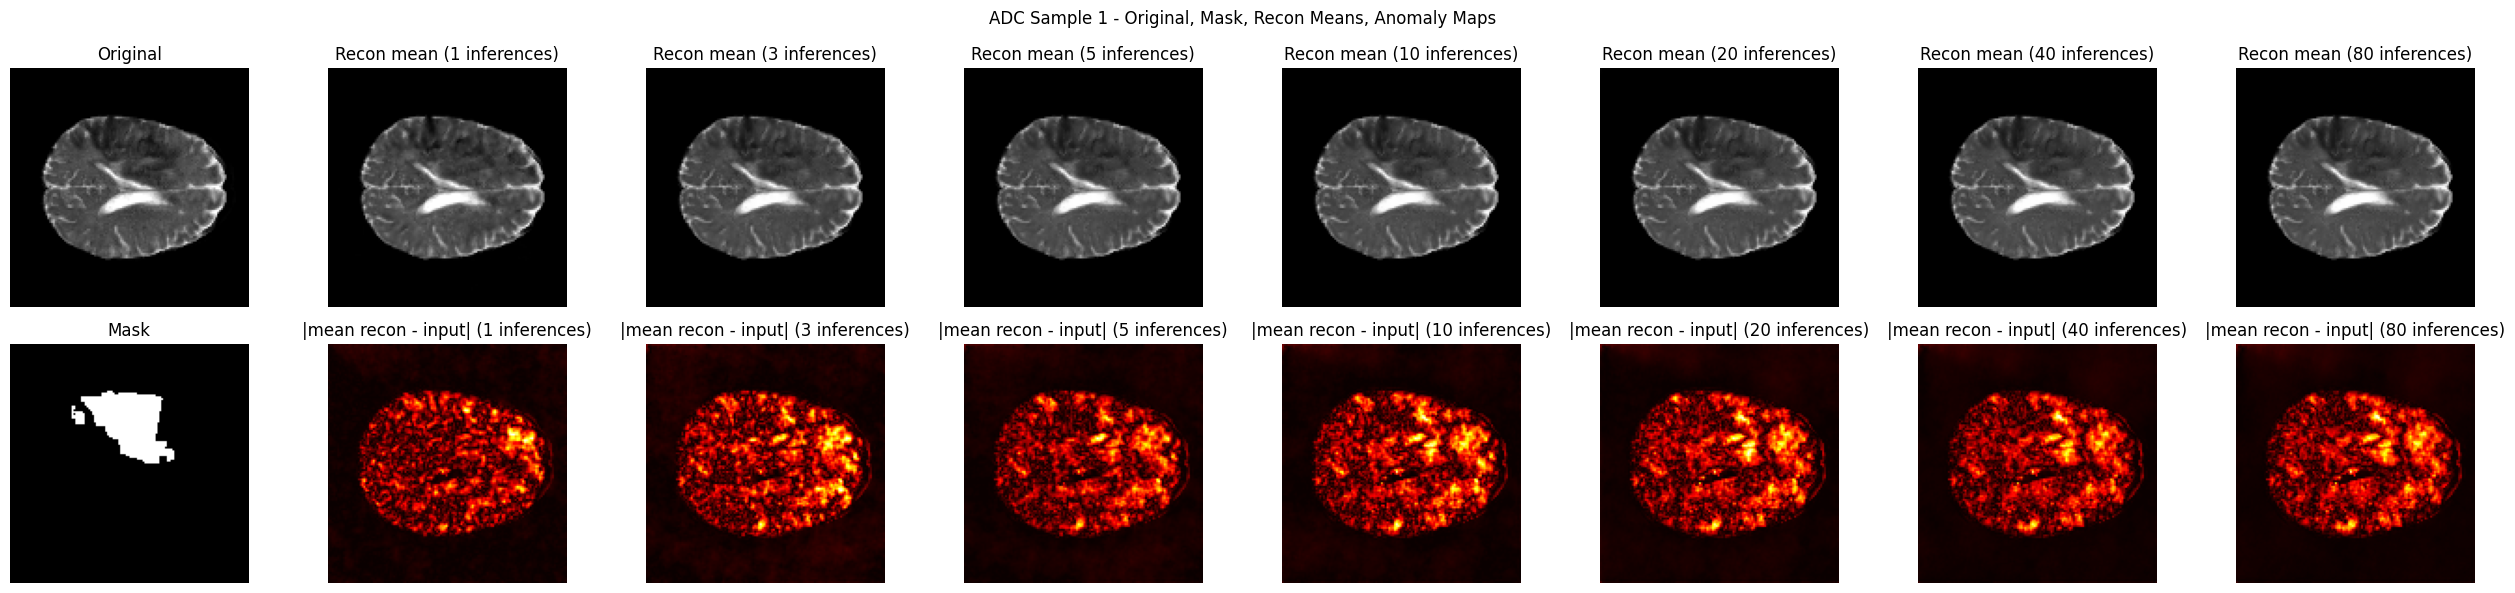

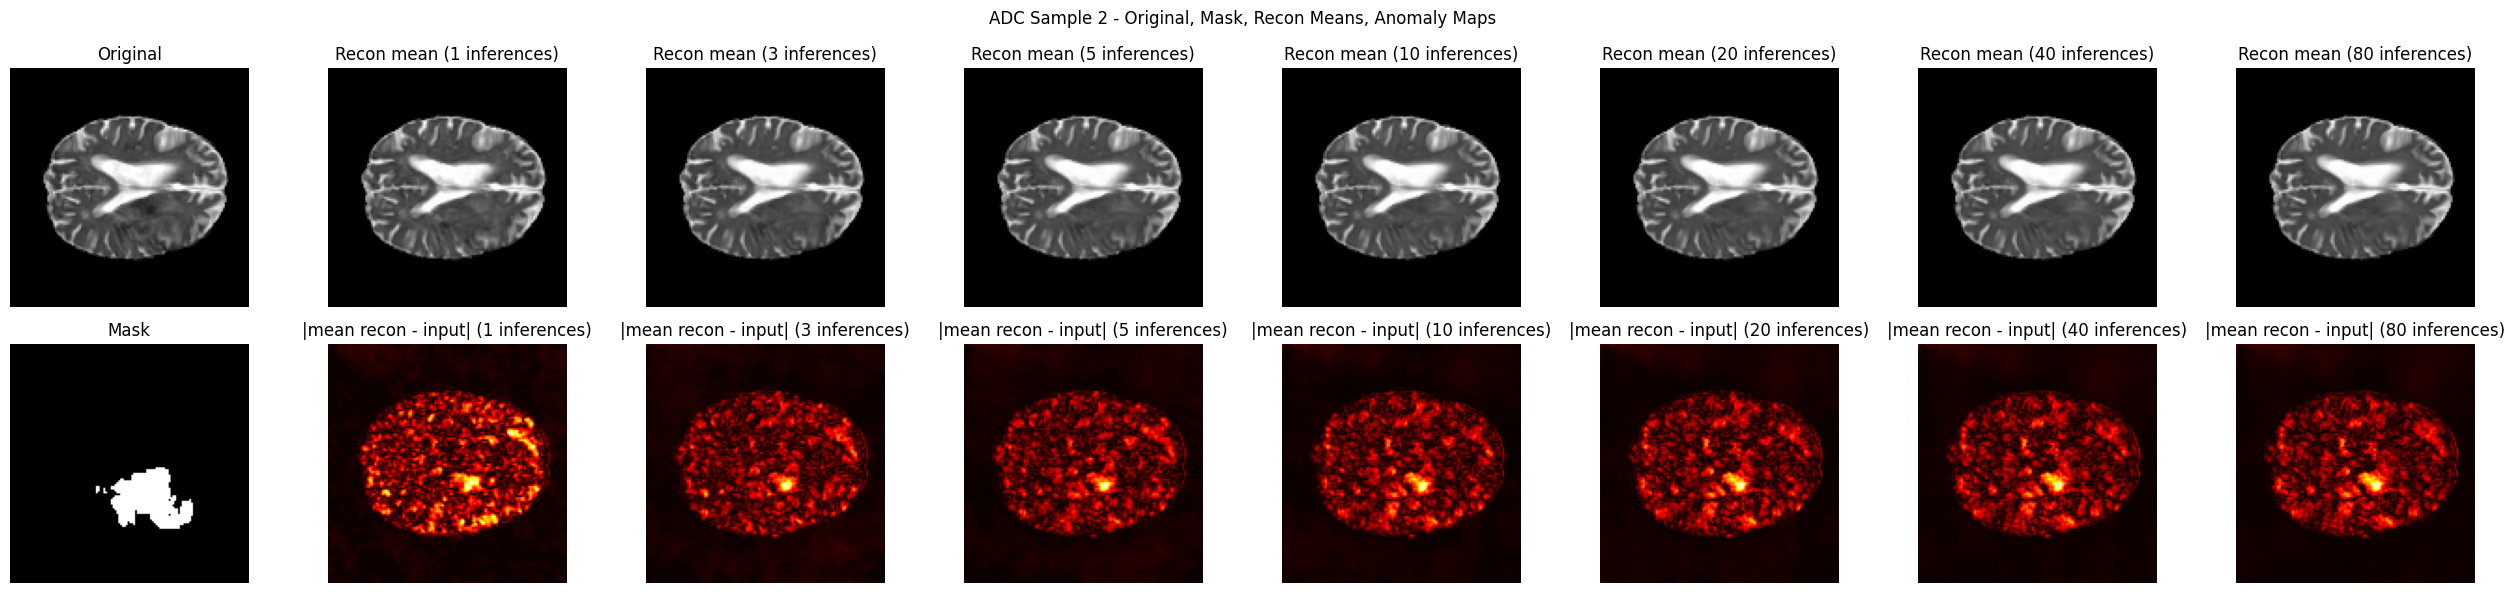

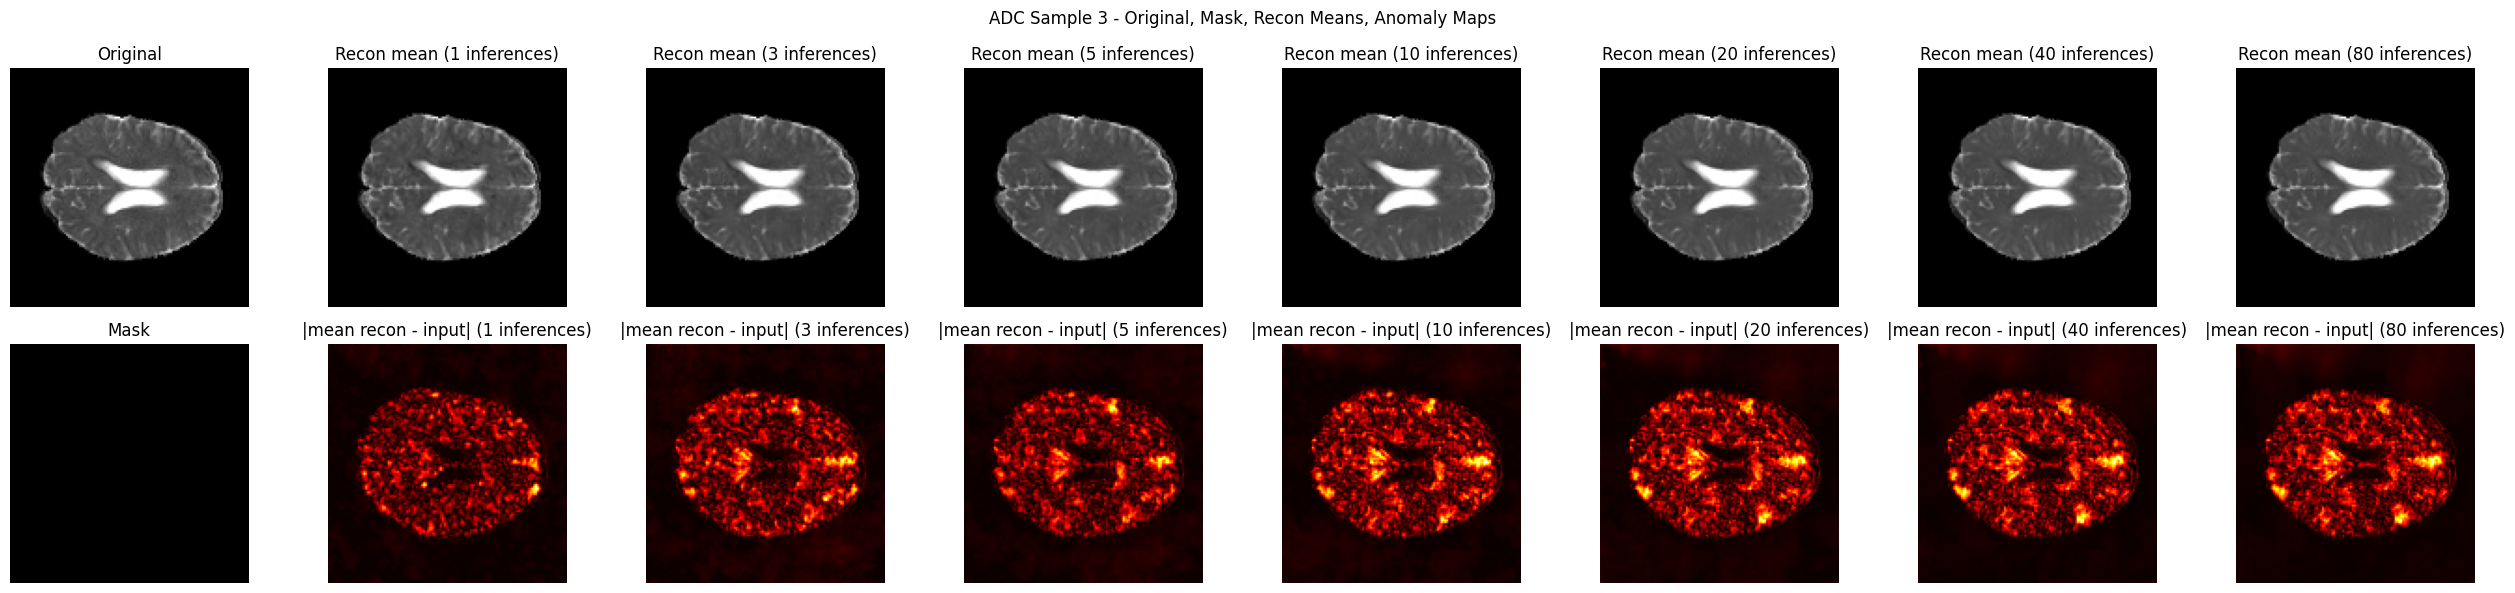

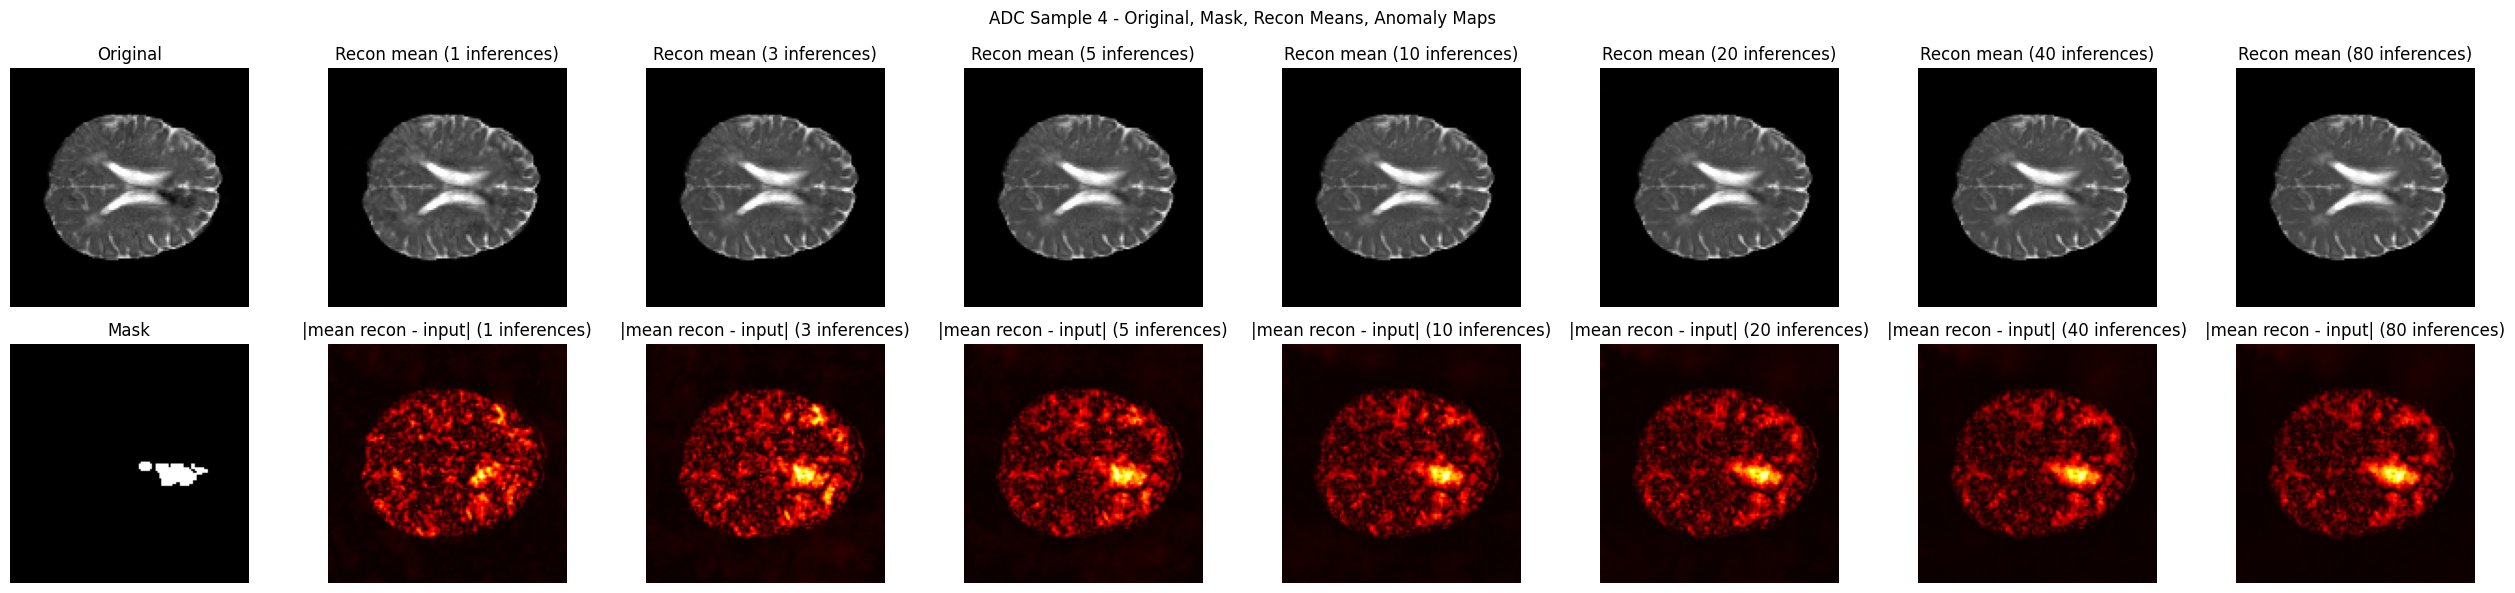

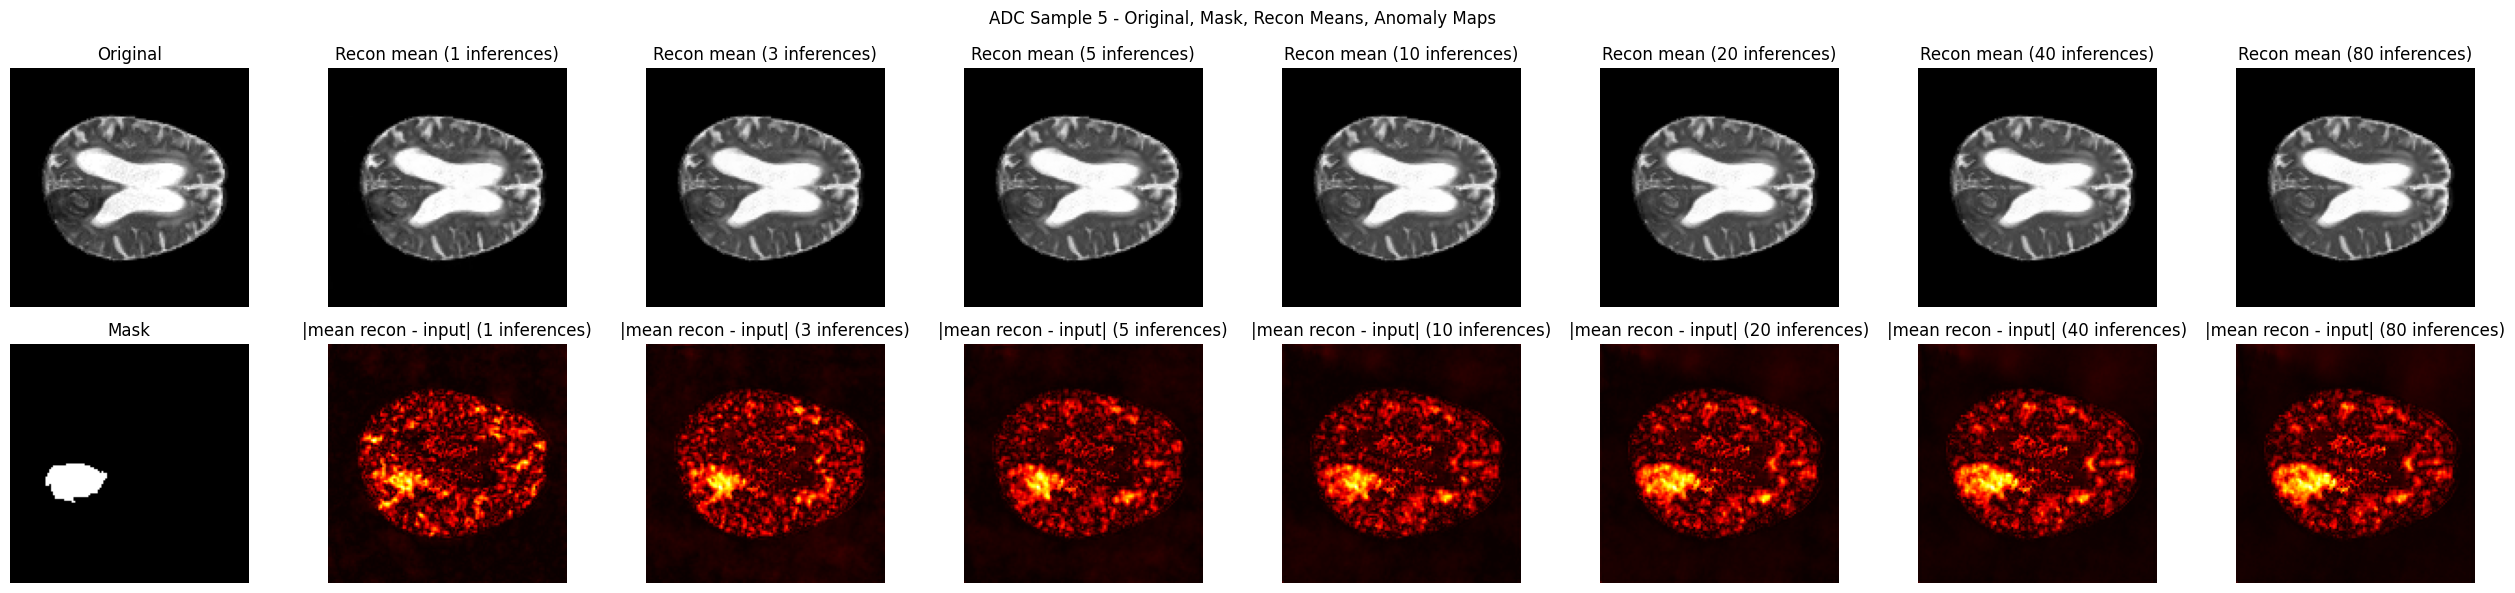

In [7]:
for sample_idx in range(5):
    n_cols = len(n_inferences_list) + 1

    fig, axs = plt.subplots(2, n_cols, figsize=(3.2 * n_cols, 6))

    axs[0, 0].imshow(batch[sample_idx, 0].detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
    axs[0, 0].set_title("Original")
    axs[0, 0].axis("off")

    axs[1, 0].imshow(mask_batch[sample_idx, 0].detach().cpu(), cmap="gray")
    axs[1, 0].set_title("Mask")
    axs[1, 0].axis("off")


    for j, n_inf in enumerate(n_inferences_list, start=1):
        axs[0, j].imshow(recon_means[n_inf][sample_idx, 0].detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
        axs[0, j].set_title(f"Recon mean ({n_inf} inferences)")
        axs[0, j].axis("off")

        axs[1, j].imshow(anomaly_maps[n_inf][sample_idx, 0].detach().cpu(), cmap="hot")
        axs[1, j].set_title(f"|mean recon - input| ({n_inf} inferences)")
        axs[1, j].axis("off")

    plt.suptitle(f"ADC Sample {sample_idx + 1} - Original, Mask, Recon Means, Anomaly Maps")
    plt.tight_layout()
    plt.show()

In [8]:
best_threshold = 0.04

In [9]:
def dice_score(pred, target, eps=1e-8):
    pred = pred.float()
    target = target.float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice_per_sample = (2.0 * intersection + eps) / (union + eps)
    return dice_per_sample.mean()

In [10]:
anomaly_maps.keys()
print(anomaly_maps[1].shape)

torch.Size([40, 1, 128, 128])


In [11]:
mean_dice_per_nb_inferences = {}
std_dice_per_nb_inferences = {}

In [12]:
for num_inferences in anomaly_maps.keys():
    
    dices = []

    for image_idx in range(anomaly_maps[num_inferences].shape[0]):
        
        # compute the dice score for this anomaly map and the corresponding mask
        
        pred_mask = (anomaly_maps[num_inferences][image_idx] > best_threshold).float()


        dice = dice_score(pred_mask, mask_batch[image_idx])

        dices.append(dice.item())

    mean_dice_per_nb_inferences[num_inferences] = np.mean(dices)
    std_dice_per_nb_inferences[num_inferences] = np.std(dices)


In [13]:
for num_inf, mean_dice in mean_dice_per_nb_inferences.items():
    print(f"Number of inferences: {num_inf}, Mean Dice Score: {mean_dice:.4f}, std: {std_dice_per_nb_inferences[num_inf]:.4f}")

Number of inferences: 1, Mean Dice Score: 0.3326, std: 0.1858
Number of inferences: 3, Mean Dice Score: 0.3946, std: 0.2220
Number of inferences: 5, Mean Dice Score: 0.4242, std: 0.2336
Number of inferences: 10, Mean Dice Score: 0.4444, std: 0.2362
Number of inferences: 20, Mean Dice Score: 0.4549, std: 0.2422
Number of inferences: 40, Mean Dice Score: 0.4681, std: 0.2470
Number of inferences: 80, Mean Dice Score: 0.4721, std: 0.2506


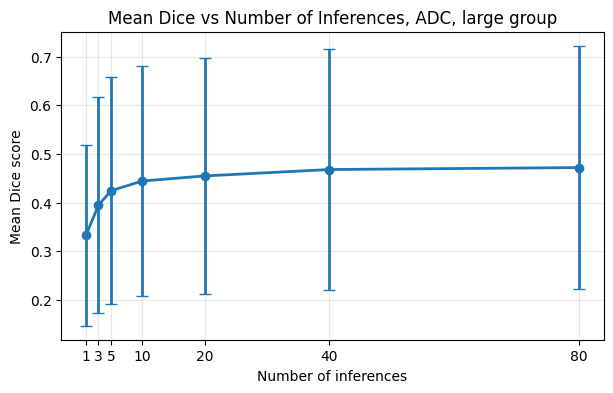

In [14]:
# Plot mean Dice score as a function of number of inferences with error bars (std)
x = sorted(mean_dice_per_nb_inferences.keys())
y = [mean_dice_per_nb_inferences[k] for k in x]
yerr = [std_dice_per_nb_inferences[k] for k in x]

plt.figure(figsize=(7, 4))
plt.errorbar(x, y, yerr=yerr, marker="o", linewidth=2, capsize=4)
plt.xticks(x)
plt.xlabel("Number of inferences")
plt.ylabel("Mean Dice score")
plt.title("Mean Dice vs Number of Inferences, ADC, large group")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
mean_dice_per_nb_inferences_filtered_maps = {}
std_dice_per_nb_inferences_filtered_maps = {}

In [16]:
for num_inferences in anomaly_maps.keys():
    
    dices = []

    for image_idx in range(anomaly_maps[num_inferences].shape[0]):
        
        # compute the dice score for this anomaly map and the corresponding mask
        
        filtered_anomaly_map = median_filter(anomaly_maps[num_inferences][image_idx].cpu(), size=7)

        pred_mask = (torch.Tensor(filtered_anomaly_map) > best_threshold).float()


        dice = dice_score(pred_mask, mask_batch[image_idx].cpu())

        dices.append(dice.item())

    mean_dice_per_nb_inferences_filtered_maps[num_inferences] = np.mean(dices)
    std_dice_per_nb_inferences_filtered_maps[num_inferences] = np.std(dices)



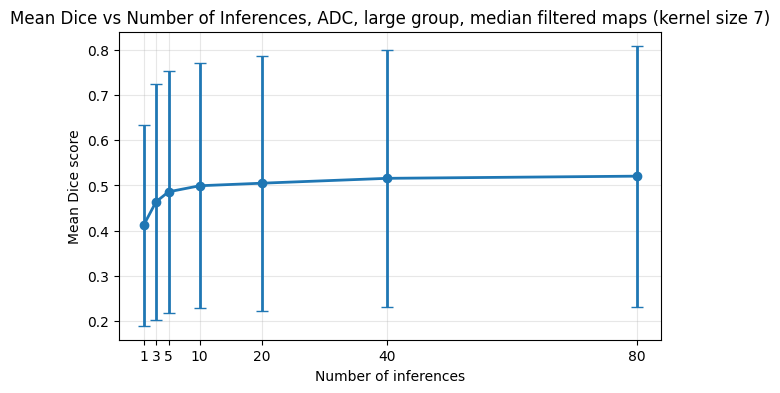

In [17]:
# Plot mean Dice score as a function of number of inferences
x = sorted(mean_dice_per_nb_inferences_filtered_maps.keys())
y = [mean_dice_per_nb_inferences_filtered_maps[k] for k in x]
yerr = [std_dice_per_nb_inferences_filtered_maps[k] for k in x]

plt.figure(figsize=(7, 4))
plt.errorbar(x, y, yerr=yerr, marker="o", linewidth=2, capsize=4)
plt.xticks(x)
plt.xlabel("Number of inferences")
plt.ylabel("Mean Dice score")
plt.title("Mean Dice vs Number of Inferences, ADC, large group, median filtered maps (kernel size 7)")
plt.grid(True, alpha=0.3)
plt.show()

### **Faire pareil avec FLAIR**

In [2]:
EXPERIMENT_DIR = Path("./experiment_3/exp_3_2")
CONFIG_PATH = EXPERIMENT_DIR / "config.json"
MODEL_PATH = EXPERIMENT_DIR / "models" / "exp_3_2_best_model.pth"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Could not find config at {CONFIG_PATH.resolve()}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Could not find model at {MODEL_PATH.resolve()}")

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

# "args" namespace compatible with define_instance() and dataset classes.
args = argparse.Namespace(**config)

configured_root = Path(str(args.root_dir))
repo_root = Path.cwd().resolve()
if repo_root.name == "2d_ddpm":
    repo_root = repo_root.parent

if configured_root.exists():
    root_dir = configured_root
else:
    root_dir = repo_root.parent

args.root_dir = str(root_dir) + "/"
print(f"Loaded config: {CONFIG_PATH}")
print(f"Using root_dir: {args.root_dir}")
print(f"Model path: {MODEL_PATH}")

Loaded config: experiment_3/exp_3_2/config.json
Using root_dir: /bettik/PROJECTS/pr-gin5_aini/fehrdelt/
Model path: experiment_3/exp_3_2/models/exp_3_2_best_model.pth


In [3]:
DEVICE_TYPE = "cuda:0" if torch.cuda.is_available() else "cpu"
device = torch.device(DEVICE_TYPE)
set_determinism(0)

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)

model = define_instance(args, "network_def").to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(
    num_train_timesteps=args.noise["num_timesteps_full_noise"],
    schedule=args.noise["schedule"],
    octaves=args.noise["simplex_octaves"],
    persistence=args.noise["simplex_persistence"],
    frequency=args.noise["simplex_frequency"],
    normalize=args.noise["normalize"],
)

print(f"Device: {device}")
print("Model and scheduler loaded.")

Device: cuda:0
Model and scheduler loaded.


In [4]:
# Load SOOP large-group FLAIR paths using the project dataset helper.
n_images = 40
soop_large = SOOP_large_only(args, batch_size=n_images, num_workers=4, num_images_to_load=n_images)


selected_image_paths = soop_large.test_anomaly_large_images[:n_images]
selected_mask_paths = soop_large.large_group_masks[:n_images]

if len(selected_image_paths) == 0:
    raise RuntimeError("No SOOP large-group FLAIR images found with current root_dir.")

flair_2d_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(args.image_size, args.image_size)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0, bins=1000),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=700.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
    ]
)

mask_2d_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=(args.image_size, args.image_size)),
    ]
)

flair_ds = CacheDataset(data=selected_image_paths, transform=flair_2d_transforms)
mask_ds = CacheDataset(data=selected_mask_paths, transform=mask_2d_transforms)

flair_loader = DataLoader(flair_ds, batch_size=n_images, shuffle=False, num_workers=2, pin_memory=True)
mask_loader = DataLoader(mask_ds, batch_size=n_images, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(flair_loader)).to(device)
mask_batch = (next(iter(mask_loader)).to(device) > 0).float()

print(f"Loaded {len(selected_image_paths)} SOOP large-group FLAIR images.")


Loading dataset: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:07<00:00,  5.17it/s]


Loaded 40 SOOP large-group FLAIR images.


In [7]:
timesteps = 150  # best value used for SOOP large group in anomaly_detection_inference.py
n_inferences_list = [1, 3, 5, 10, 20, 40, 80]

max_n_inf = max(n_inferences_list)

# Generate once, reuse for all smaller inference counts.
runs = []
for _ in tqdm(range(max_n_inf)):
    recon = my_sample(batch, infer_scheduler, timesteps=timesteps, return_intermediates=False)
    runs.append(recon.unsqueeze(0))

runs = torch.cat(runs, dim=0)  # [max_n_inf, B, C, H, W]

recon_cumsum = runs.cumsum(dim=0)
abs_diff_cumsum = torch.abs(runs - batch.unsqueeze(0)).cumsum(dim=0)

recon_means = {}
anomaly_maps = {}

for n_inf in n_inferences_list:
    mean_recon = recon_cumsum[n_inf - 1] / n_inf
    recon_means[n_inf] = mean_recon
    anomaly_maps[n_inf] = torch.abs(mean_recon - batch)

print(f"Finished {max_n_inf} reconstructions and reused prefixes for all requested averages.")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [39:29<00:00, 29.62s/it]


Finished 80 reconstructions and reused prefixes for all requested averages.


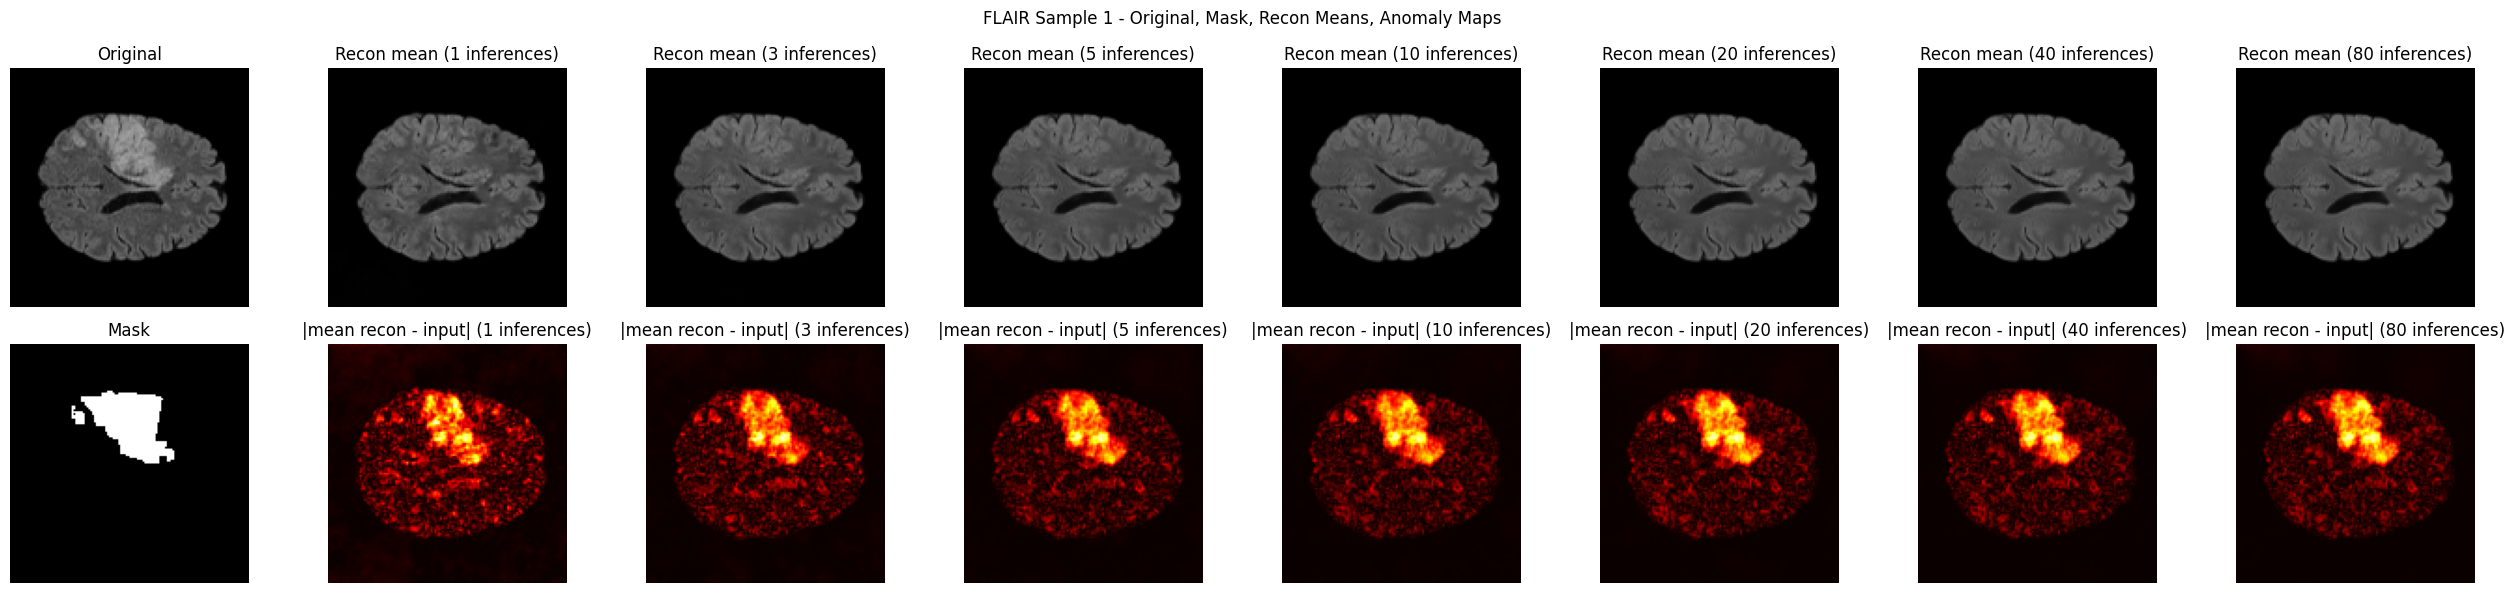

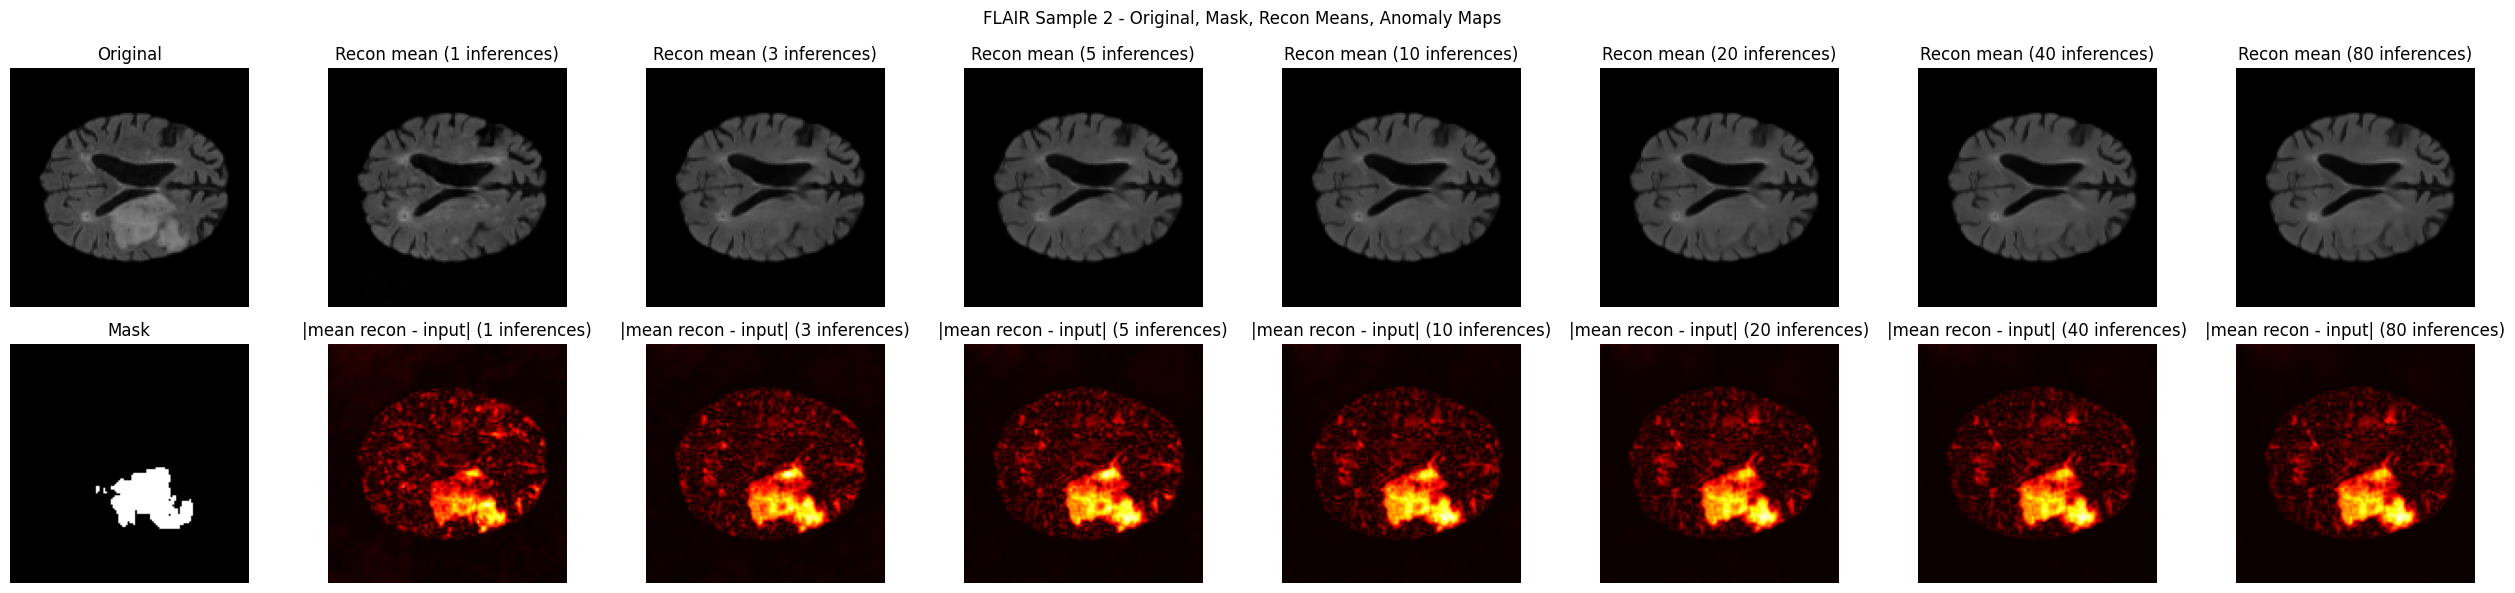

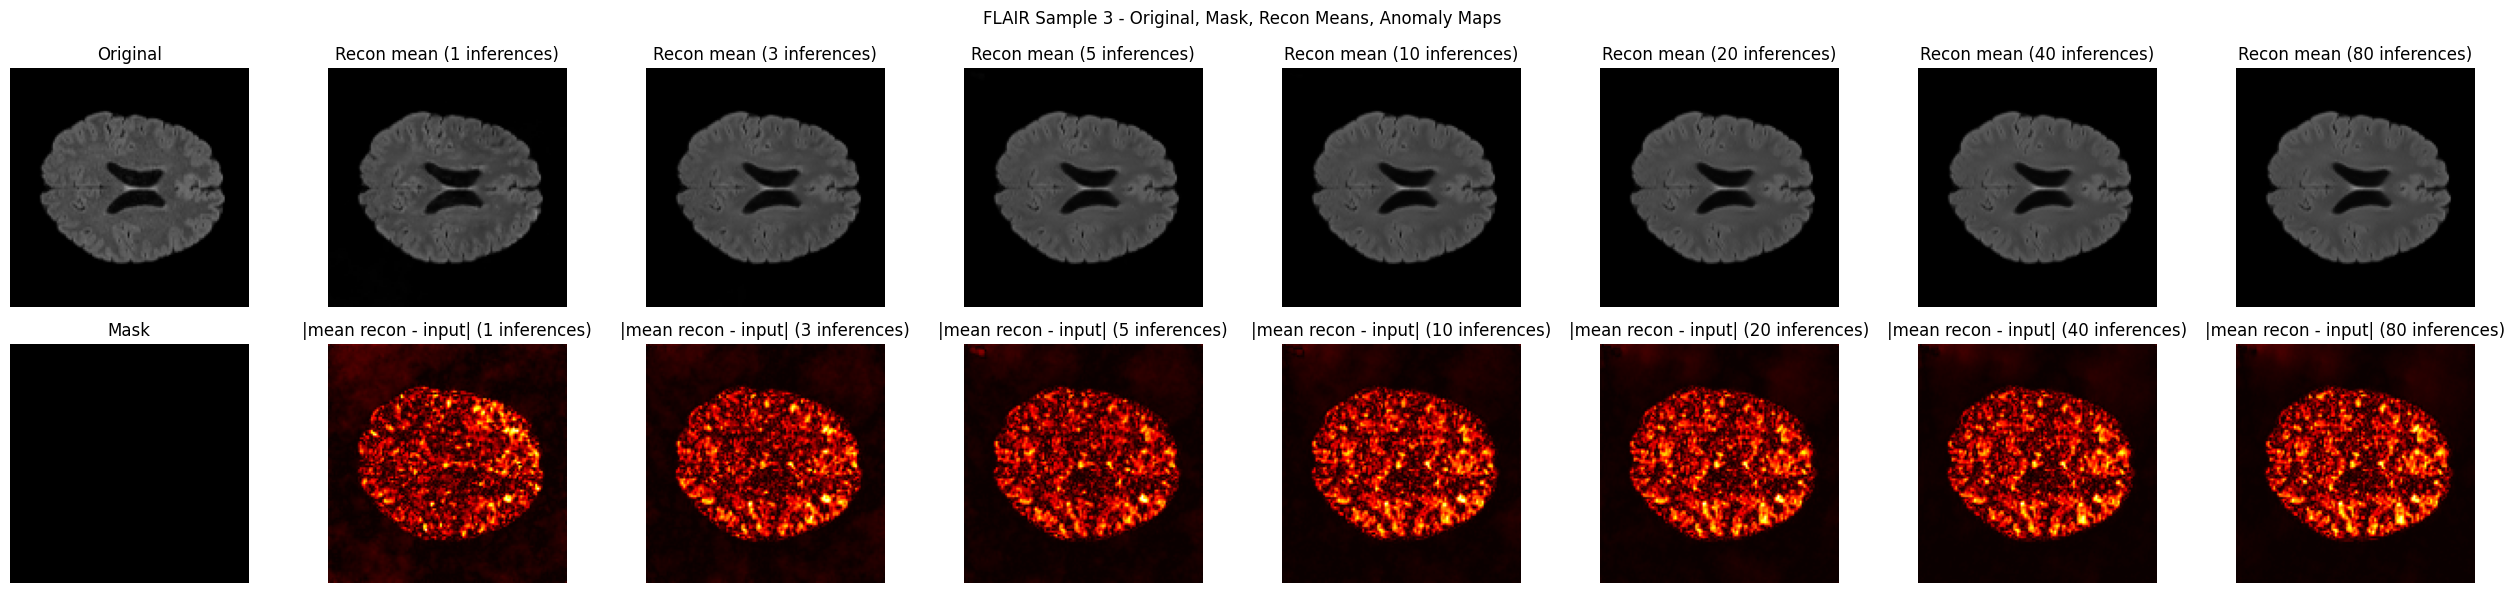

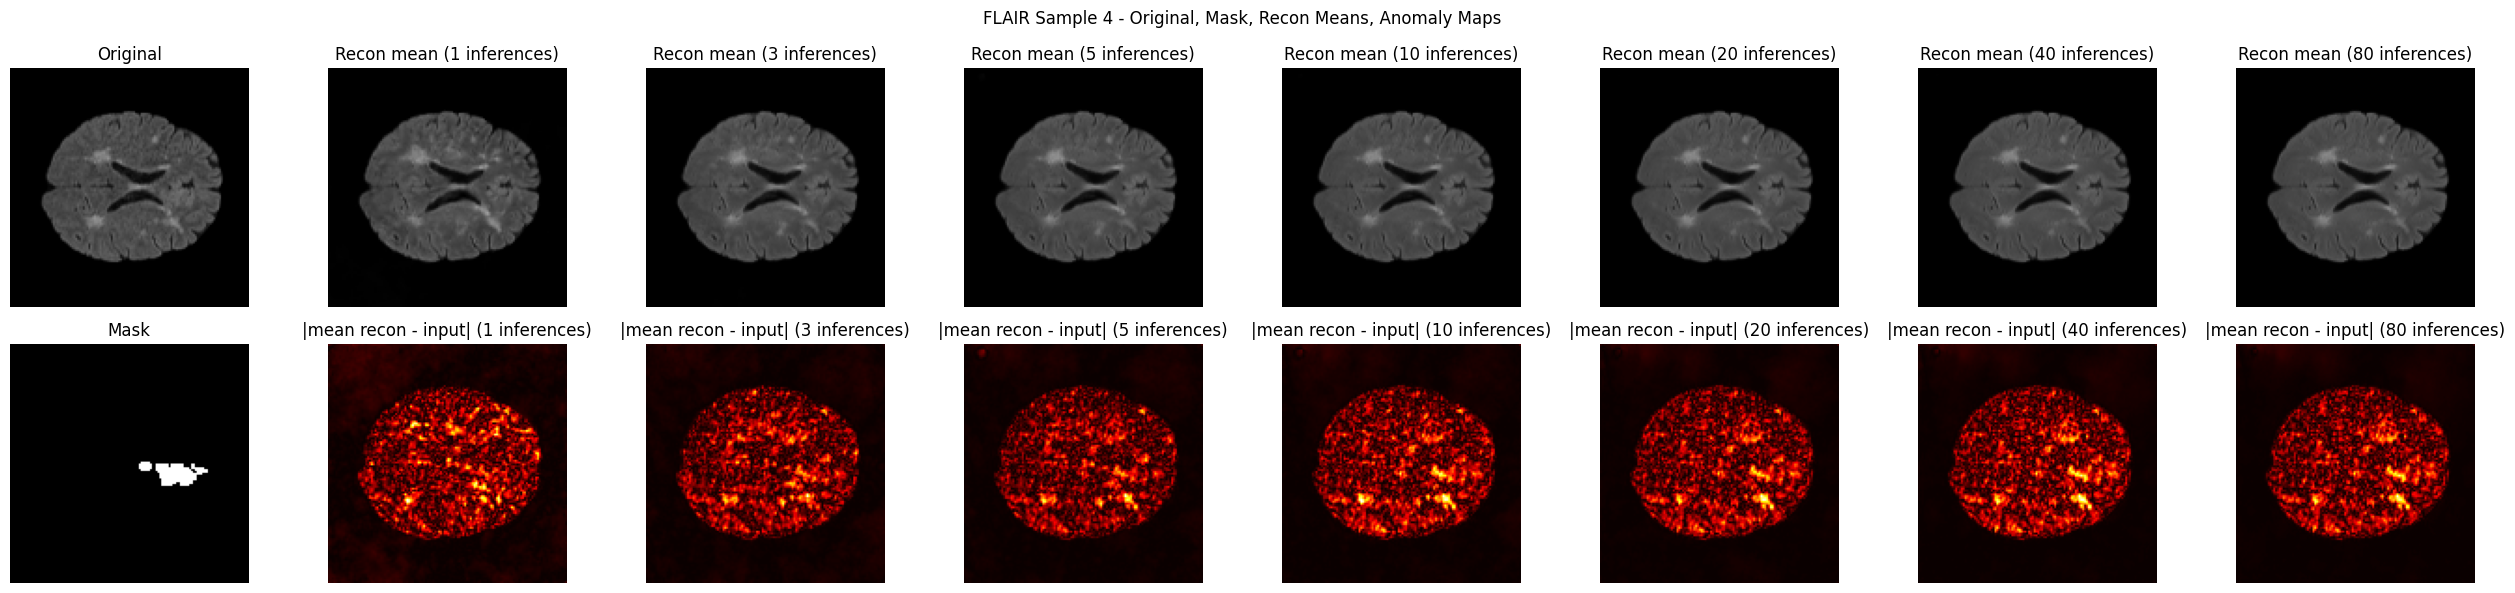

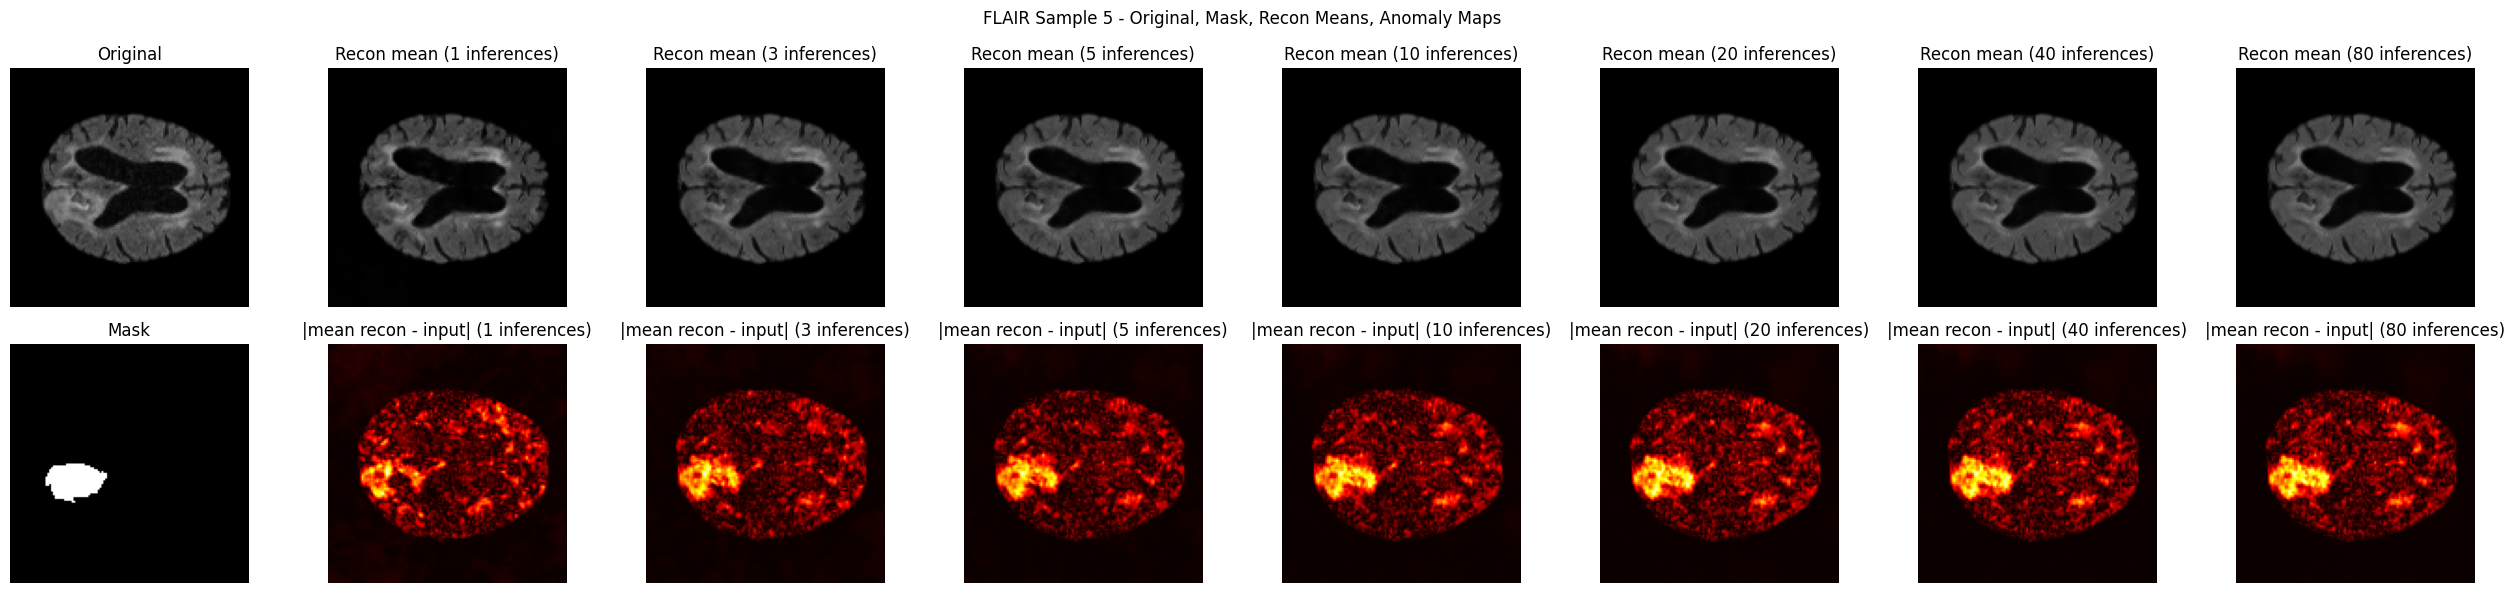

In [8]:
for sample_idx in range(5):
    n_cols = len(n_inferences_list) + 1

    fig, axs = plt.subplots(2, n_cols, figsize=(3.2 * n_cols, 6))

    axs[0, 0].imshow(batch[sample_idx, 0].detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
    axs[0, 0].set_title("Original")
    axs[0, 0].axis("off")

    axs[1, 0].imshow(mask_batch[sample_idx, 0].detach().cpu(), cmap="gray")
    axs[1, 0].set_title("Mask")
    axs[1, 0].axis("off")


    for j, n_inf in enumerate(n_inferences_list, start=1):
        axs[0, j].imshow(recon_means[n_inf][sample_idx, 0].detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
        axs[0, j].set_title(f"Recon mean ({n_inf} inferences)")
        axs[0, j].axis("off")

        axs[1, j].imshow(anomaly_maps[n_inf][sample_idx, 0].detach().cpu(), cmap="hot")
        axs[1, j].set_title(f"|mean recon - input| ({n_inf} inferences)")
        axs[1, j].axis("off")

    plt.suptitle(f"FLAIR Sample {sample_idx + 1} - Original, Mask, Recon Means, Anomaly Maps")
    plt.tight_layout()
    plt.show()

In [9]:
best_threshold = 0.04

In [10]:
def dice_score(pred, target, eps=1e-8):
    pred = pred.float()
    target = target.float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice_per_sample = (2.0 * intersection + eps) / (union + eps)
    return dice_per_sample.mean()

In [11]:
anomaly_maps.keys()
print(anomaly_maps[1].shape)

torch.Size([40, 1, 128, 128])


In [12]:
mean_dice_per_nb_inferences = {}
std_dice_per_nb_inferences = {}

In [13]:
for num_inferences in anomaly_maps.keys():
    
    dices = []

    for image_idx in range(anomaly_maps[num_inferences].shape[0]):
        
        # compute the dice score for this anomaly map and the corresponding mask
        
        pred_mask = (anomaly_maps[num_inferences][image_idx] > best_threshold).float()


        dice = dice_score(pred_mask, mask_batch[image_idx])

        dices.append(dice.item())

    mean_dice_per_nb_inferences[num_inferences] = np.mean(dices)
    std_dice_per_nb_inferences[num_inferences] = np.std(dices)


In [14]:
for num_inf, mean_dice in mean_dice_per_nb_inferences.items():
    print(f"Number of inferences: {num_inf}, Mean Dice Score: {mean_dice:.4f}, std: {std_dice_per_nb_inferences[num_inf]:.4f}")

Number of inferences: 1, Mean Dice Score: 0.3306, std: 0.1739
Number of inferences: 3, Mean Dice Score: 0.3702, std: 0.1842
Number of inferences: 5, Mean Dice Score: 0.3855, std: 0.1864
Number of inferences: 10, Mean Dice Score: 0.4083, std: 0.1995
Number of inferences: 20, Mean Dice Score: 0.4134, std: 0.2016
Number of inferences: 40, Mean Dice Score: 0.4168, std: 0.2038
Number of inferences: 80, Mean Dice Score: 0.4191, std: 0.2041


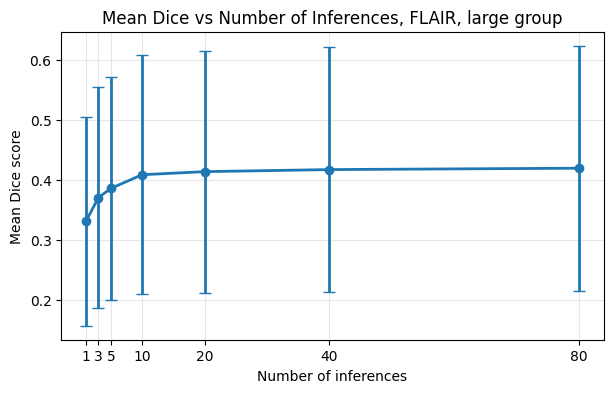

In [15]:
# Plot mean Dice score as a function of number of inferences with error bars (std)
x = sorted(mean_dice_per_nb_inferences.keys())
y = [mean_dice_per_nb_inferences[k] for k in x]
yerr = [std_dice_per_nb_inferences[k] for k in x]

plt.figure(figsize=(7, 4))
plt.errorbar(x, y, yerr=yerr, marker="o", linewidth=2, capsize=4)
plt.xticks(x)
plt.xlabel("Number of inferences")
plt.ylabel("Mean Dice score")
plt.title("Mean Dice vs Number of Inferences, FLAIR, large group")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
mean_dice_per_nb_inferences_filtered_maps = {}
std_dice_per_nb_inferences_filtered_maps = {}

In [17]:
for num_inferences in anomaly_maps.keys():
    
    dices = []

    for image_idx in range(anomaly_maps[num_inferences].shape[0]):
        
        # compute the dice score for this anomaly map and the corresponding mask
        
        filtered_anomaly_map = median_filter(anomaly_maps[num_inferences][image_idx].cpu(), size=7)

        pred_mask = (torch.Tensor(filtered_anomaly_map) > best_threshold).float()


        dice = dice_score(pred_mask, mask_batch[image_idx].cpu())

        dices.append(dice.item())

    mean_dice_per_nb_inferences_filtered_maps[num_inferences] = np.mean(dices)
    std_dice_per_nb_inferences_filtered_maps[num_inferences] = np.std(dices)



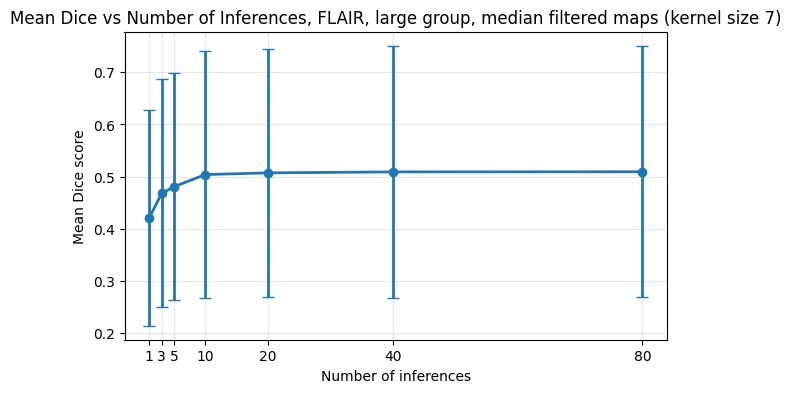

In [18]:
# Plot mean Dice score as a function of number of inferences
x = sorted(mean_dice_per_nb_inferences_filtered_maps.keys())
y = [mean_dice_per_nb_inferences_filtered_maps[k] for k in x]
yerr = [std_dice_per_nb_inferences_filtered_maps[k] for k in x]

plt.figure(figsize=(7, 4))
plt.errorbar(x, y, yerr=yerr, marker="o", linewidth=2, capsize=4)
plt.xticks(x)
plt.xlabel("Number of inferences")
plt.ylabel("Mean Dice score")
plt.title("Mean Dice vs Number of Inferences, FLAIR, large group, median filtered maps (kernel size 7)")
plt.grid(True, alpha=0.3)
plt.show()